<a href="https://colab.research.google.com/github/imshubhangisingh/Shared-E-bike-Demand-Analysis/blob/main/Shared_E_Bike_Demand_Data_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Problem Statement:

- Which variables are significant in predicting the demand for shared electric cycles in the Indian market?

- How well those variables describe the electric cycle demands?

In [ ]:
import numpy as np # linear algebra
import pandas as pd

from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing data
df = pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089")

In [ ]:
# no of rows amd columns in dataset
print(f"# rows: {df.shape[0]} \n# columns: {df.shape[1]}")

# rows: 10886 
# columns: 12


In [ ]:
df.columns #Columns in the Dataset

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [ ]:
#Basic structure od the data set
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [ ]:
# detecting missing values in the dataset
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


There are no missing values present in the dataset.


Datatype of following attributes needs to change to proper data type


*   datetime - to datetime
*   season - to categorical
*   holiday - to categorical
*   workingday - to categorical
*   weather - to categorical

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

cat_cols= ['season', 'holiday', 'workingday', 'weather']

for col in cat_cols:
    df[col] = df[col].astype('object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  object        
 2   holiday     10886 non-null  object        
 3   workingday  10886 non-null  object        
 4   weather     10886 non-null  object        
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 1020.7+ KB


In [ ]:
df.iloc[:, 1:].describe(include='all')

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.0,10886.0,10886.0,10886.0,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,4.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,4.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2734.0,10575.0,7412.0,7192.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,NaN,NaN,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,NaN,NaN,NaN,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,NaN,NaN,NaN,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,NaN,NaN,NaN,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000



*    The dataset does not have any missing values.
*   The casual and registered attributes may have outliers as their mean and median are very far apart from each other. Moreover, the standard deviation value is also high, indicating that there is high variance in the data of these attributes.

In [ ]:
# minimum datetime and maximum datetime
print(df['datetime'].min(), df['datetime'].max())

# number of unique values in each categorical columns
df[cat_cols].melt().groupby(['variable', 'value'])[['value']].count()

2011-01-01 00:00:00 2012-12-19 23:00:00


value
variable   value       
holiday    0      10575
           1        311
season     1       2686
           2       2733
           3       2733
           4       2734
weather    1       7192
           2       2834
           3        859
           4          1
workingday 0       3474
           1       7412

Try establishing a relation between the dependent and independent variable (Dependent “Count” & Independent: Workingday, Weather, Season etc)

## **Univariate Analysis:**

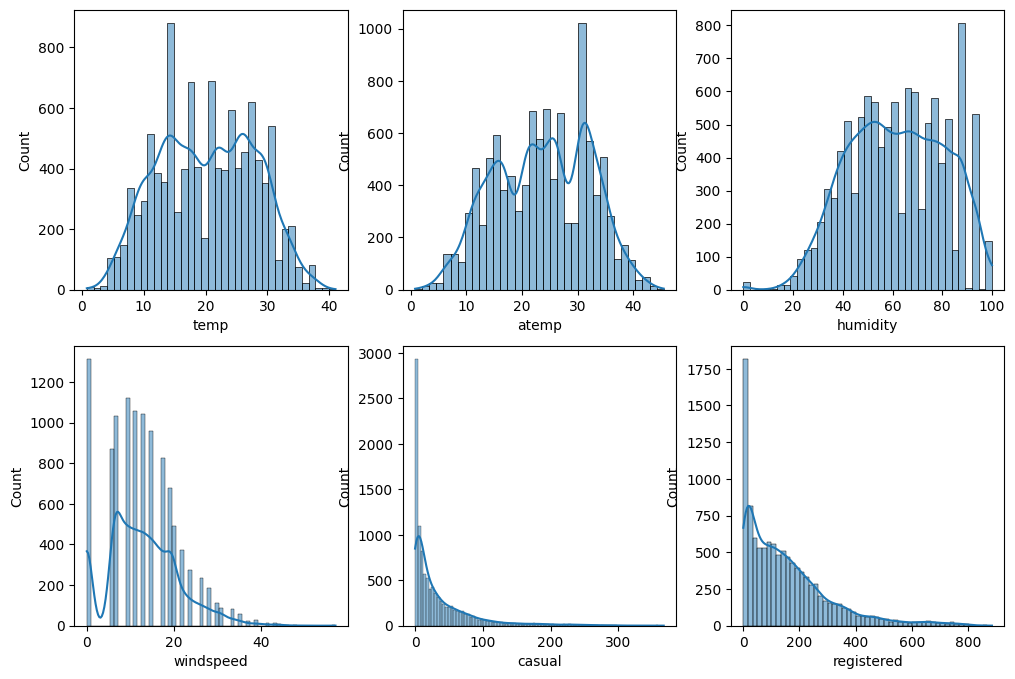

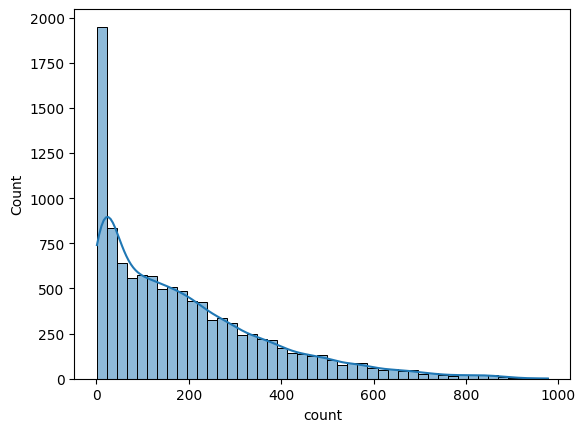

In [ ]:
# understanding the distribution for numerical variables
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered','count']
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
index = 0
for row in range(2):
  for col in range(3):
    sns.histplot(df[num_cols[index]], ax=axis[row, col], kde=True)
    index += 1
plt.show()
sns.histplot(df[num_cols[-1]], kde=True)
plt.show()

###Basic Observations from above plot

*   casual, registered and count somewhat looks like Log Normal Distribution
*   temp, atemp and humidity looks like they follows the Normal Distribution
*  windspeed follows the binomial distribution







###Plotting box plots to detect outliers in the data

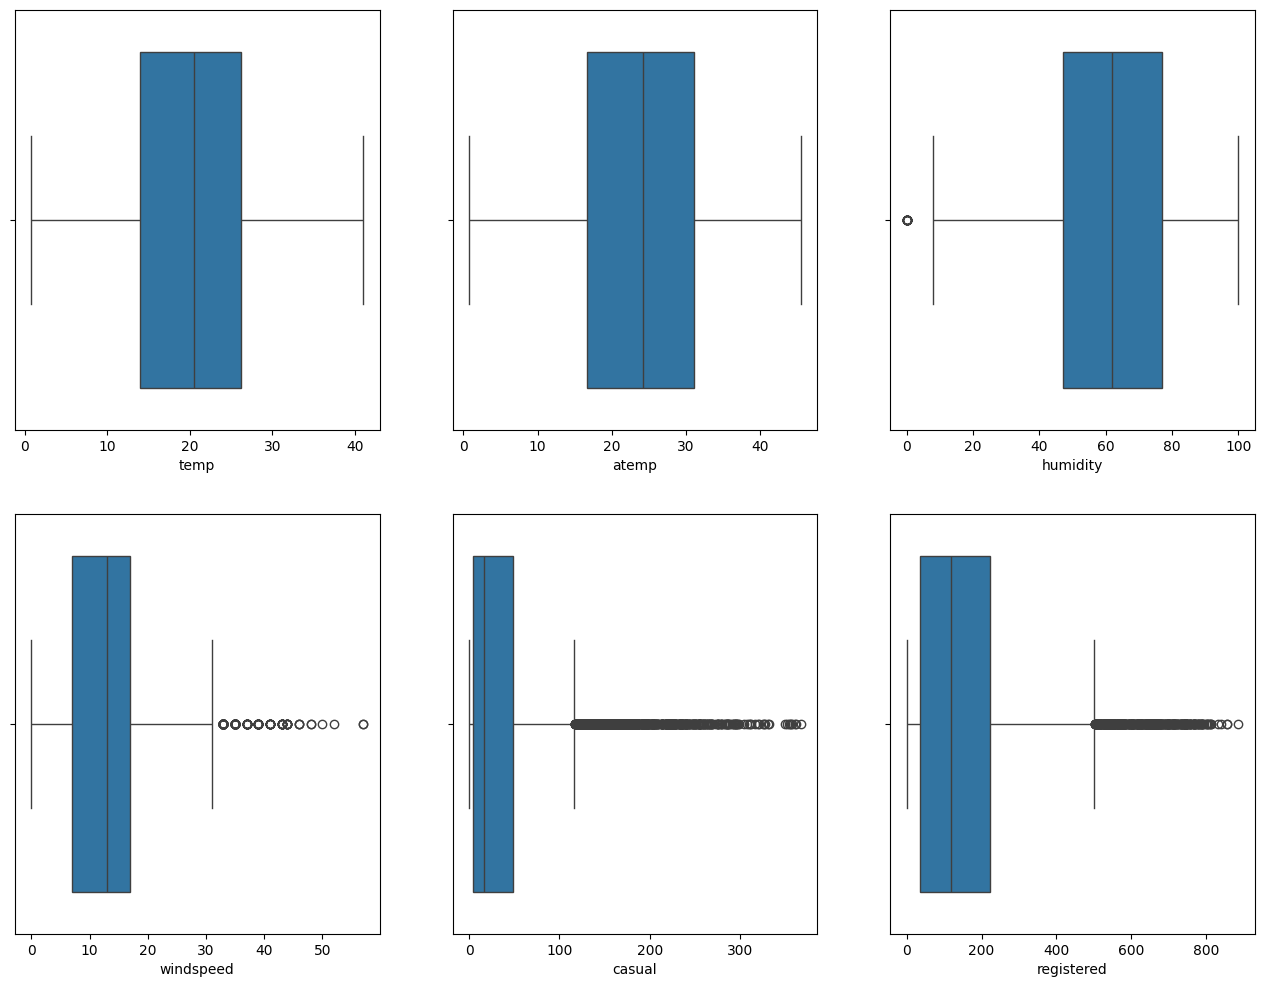

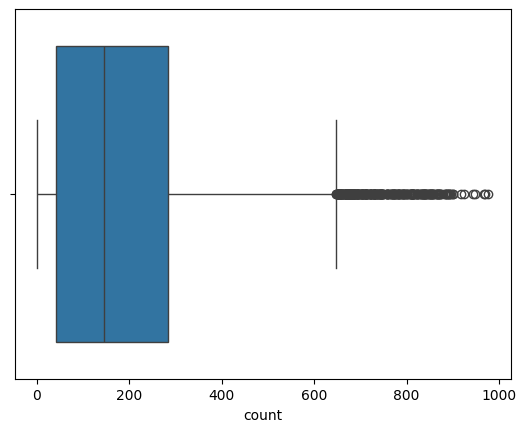

In [ ]:
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(16, 12))
index = 0
for row in range(2):
  for col in range(3):
    sns.boxplot(x=df[num_cols[index]], ax=axis[row, col])
    index += 1
plt.show()
sns.boxplot(x=df[num_cols[-1]])
plt.show()

Looks like humidity, casual, registered and count have outliers in the data.

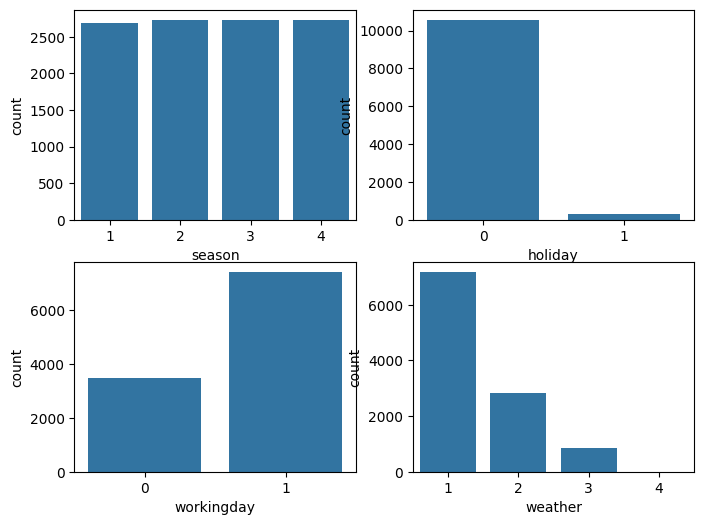

In [ ]:
# countplot of each categorical column
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))
index = 0
for row in range(2):
  for col in range(2):
    sns.countplot(data=df, x=cat_cols[index], ax=axis[row, col])
    index += 1
plt.show()

Data looks common as it should be like equal number of days in each season, more working
days and weather is mostly Clear, Few clouds, partly cloudy, partly cloudy.

## **Bi-variate Analysis**

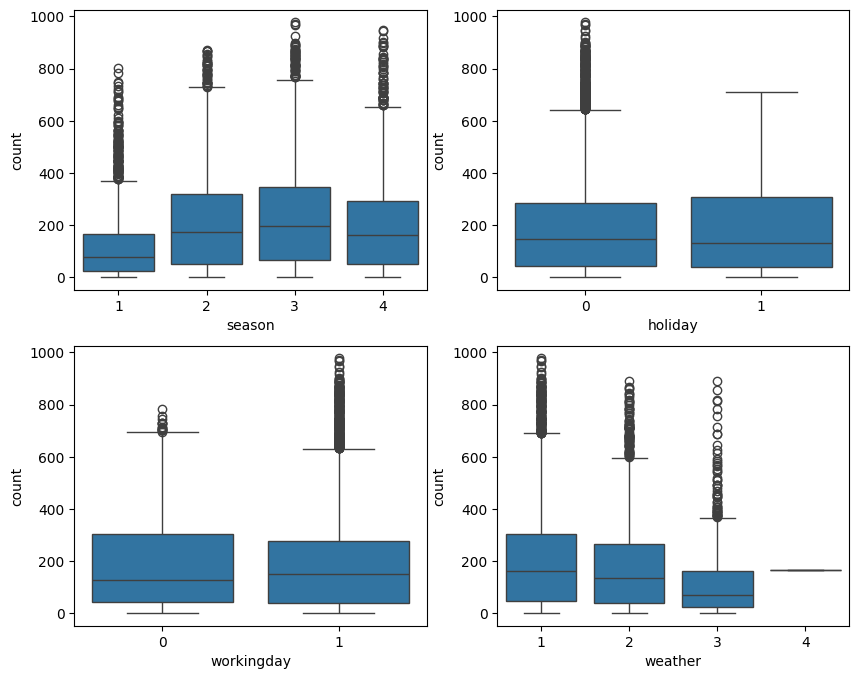

In [ ]:
 #plotting categorical variables againt count using boxplots
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
index = 0
for row in range(2):
  for col in range(2):
    sns.boxplot(data=df, x=cat_cols[index], y='count', ax=axis[row, col])
    index += 1
plt.show()



*   More bikes are rented during the summer and fall seasons as compared to other seasons.
*   On holidays, there is an increase in the number of bike rentals.
*   On weekends and holidays, slightly more bikes are rented than on working days.
*   The number of bike rentals decreases during rainy, snowy, foggy, or thunderstorm weather.



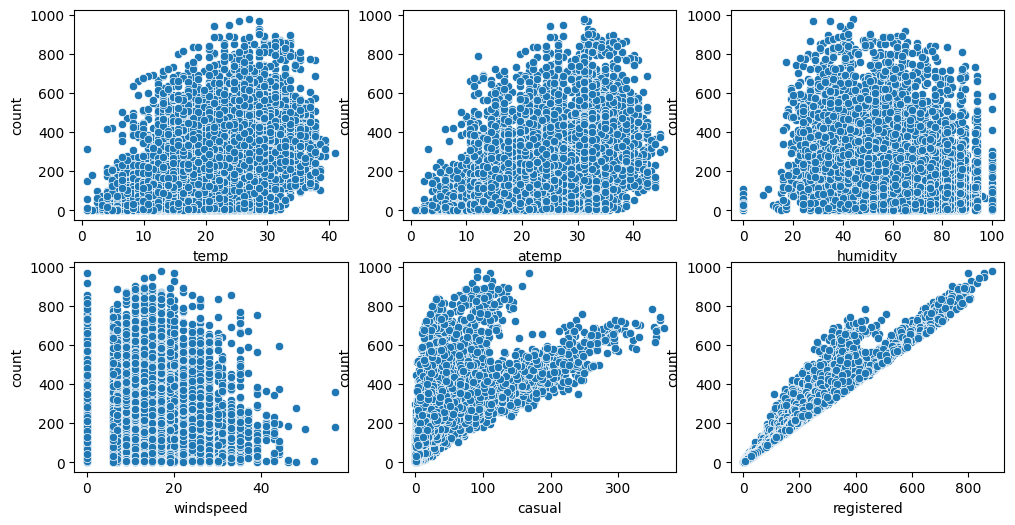

In [ ]:
# plotting numerical variables againt count using scatterplot
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
index = 0
for row in range(2):
  for col in range(3):
    sns.scatterplot(data=df, x=num_cols[index], y='count',ax=axis[row, col])
    index += 1
plt.show()



*   Whenever the humidity is less than 20, the number of bikes rented is very very low.
*   The number of bike rentals decreases when the temperature is less than 10 degrees.
*   Whenever the windspeed is greater than 35, the number of bike rentals is less.



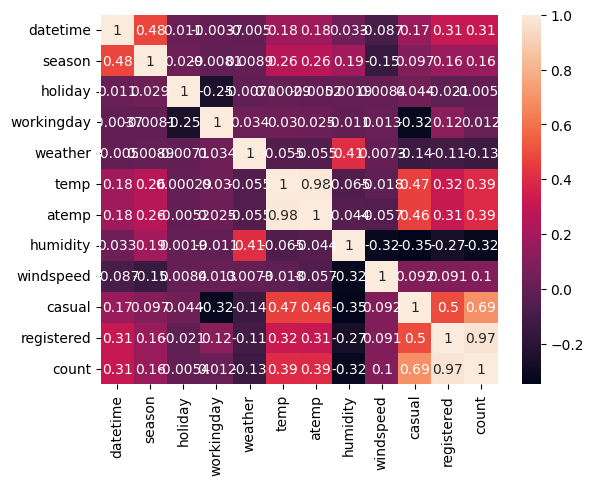

In [ ]:
# understanding the correlation between count and numerical variables
df.corr()['count']
sns.heatmap(df.corr(), annot=True)
plt.show()

# **2: Hypothesis Testing:**

### Chi-square test - to check if Weather is dependent on the season

  **Null Hypothesis (H0):** Weather is independent of the season
  
  **Alternate Hypothesis (H1):** Weather is not independent of the season
  
  **Significance level (alpha):** 0.05

In [ ]:
data_table = pd.crosstab(df['season'], df['weather'])
print("Observed values:")
data_table

Observed values:


weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


In [ ]:
val = stats.chi2_contingency(data_table)
print(val)
expected_values = val[3]
print(expected_values)
nrows, ncols = 4, 4
dof = (nrows-1)*(ncols-1)
print("degrees of freedom: ", dof)
alpha = 0.05

chi_sqr = sum([(o-e)**2/e for o, e in zip(data_table.values, expected_values)])
chi_sqr_statistic = chi_sqr[0] + chi_sqr[1]
print("chi-square test statistic: ", chi_sqr_statistic)

critical_val = stats.chi2.ppf(q=1-alpha, df=dof)
print(f"critical value: {critical_val}")

p_val = 1-stats.chi2.cdf(x=chi_sqr_statistic, df=dof)
print(f"p-value: {p_val}")

if p_val <= alpha:
  print("\nSince p-value is less than the alpha 0.05, We reject the Null Hypothesis. Meaning that\ Weather is dependent on the season.")
else:
  print("Since p-value is greater than the alpha 0.05, We do not reject the Null Hypothesis")

Chi2ContingencyResult(statistic=np.float64(49.158655596893624), pvalue=np.float64(1.549925073686492e-07), dof=9, expected_freq=array([[1.77454639e+03, 6.99258130e+02, 2.11948742e+02, 2.46738931e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80625831e+03, 7.11754180e+02, 2.15736359e+02, 2.51148264e-01]]))
[[1.77454639e+03 6.99258130e+02 2.11948742e+02 2.46738931e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80625831e+03 7.11754180e+02 2.15736359e+02 2.51148264e-01]]
degrees of freedom:  9
chi-square test statistic:  44.09441248632364
critical value: 16.918977604620448
p-value: 1.3560001579371317e-06

Since p-value is less than the alpha 0.05, We reject the Null Hypothesis. Meaning that\ Weather is dependent on the season.


<>:21: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_487/1420214636.py:21: SyntaxWarning: invalid escape sequence '\ '
  print("\nSince p-value is less than the alpha 0.05, We reject the Null Hypothesis. Meaning that\ Weather is dependent on the season.")


### Two - Sample T-Test to check if Working Day has an effect on the number of electric cycles rented :

**Null Hypothesis:** - Working day has no effect on the number of cycles being rented.

**Alternate Hypothesis:** Working day has effect on the number of cycles being rented.

**Significance level (alpha):** 0.05
We will use the 2-Sample T-Test to test the hypothess defined above

In [ ]:
data_group1 = df[df['workingday']==0]['count'].values
data_group2 = df[df['workingday']==1]['count'].values

print(np.var(data_group1), np.var(data_group2))
np.var(data_group2)// np.var(data_group1)

30171.346098942427 34040.69710674686


np.float64(1.0)

Before conducting the two-sample T-Test we need to find if the given data groups have the same variance. If the ratio of the larger data groups to the small data group is less than 4:1 then we can consider that the given data groups have equal variance.

Here, the ratio is 34040.70 / 30171.35 which is less than 4:1

In [ ]:
stats.ttest_ind(a=data_group1, b=data_group2, equal_var=True)

TtestResult(statistic=np.float64(-1.2096277376026694), pvalue=np.float64(0.22644804226361348), df=np.float64(10884.0))

Since pvalue is greater than 0.05 so we cannot reject the Null hypothesis. We don't have the sufficient evidence to say that working day has effect on the number of cycles being rented.


### ANNOVA - to check if No. of cycles rented is similar or different in different
  1. weather
  2. Season


**Null Hypothesis:** Number of cycles rented is similar in different weather and season.

**Alternate Hypothesis:** Number of cycles rented is not similar in different weather and season.

**Significance level (alpha):** 0.05

In [ ]:
# defining the data groups for the ANOVA
from statsmodels.graphics.gofplots import qqplot
gp1 = df[df['weather']==1]['count'].values
gp2 = df[df['weather']==2]['count'].values
gp3 = df[df['weather']==3]['count'].values
gp4 = df[df['weather']==4]['count'].values

gp5 = df[df['season']==1]['count'].values
gp6 = df[df['season']==2]['count'].values
gp7 = df[df['season']==3]['count'].values
gp8 = df[df['season']==4]['count'].values
groups=[gp1,gp2,gp3,gp4,gp5,gp6,gp7,gp8]

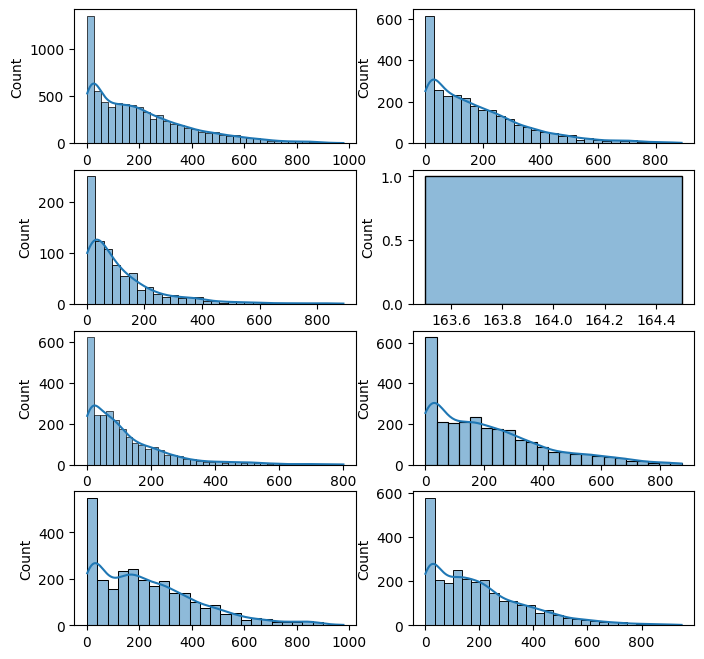

In [ ]:
fig, axis = plt.subplots(nrows=4, ncols=2, figsize=(8, 8))

index = 0
for row in range(4):
    for col in range(2):
        sns.histplot(groups[index], ax=axis[row, col], kde=True)
        index += 1

plt.show()

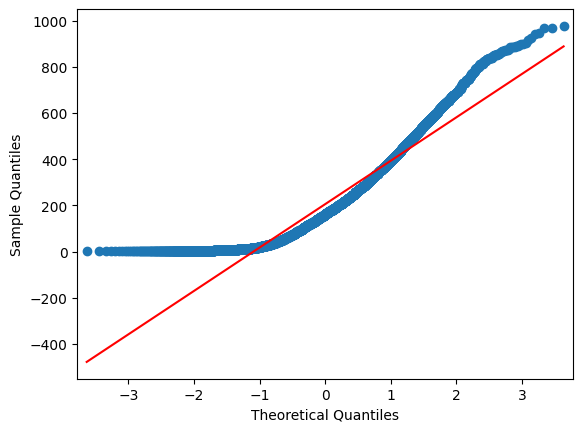

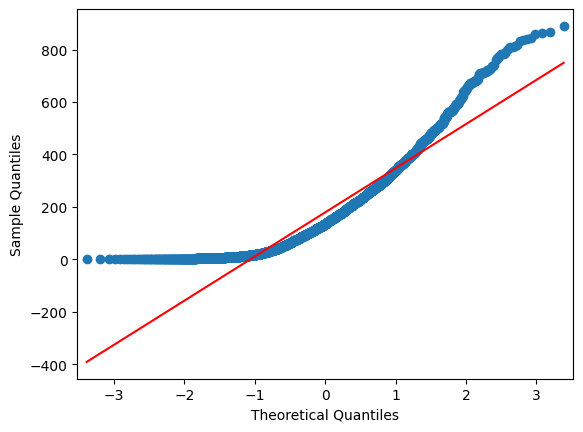

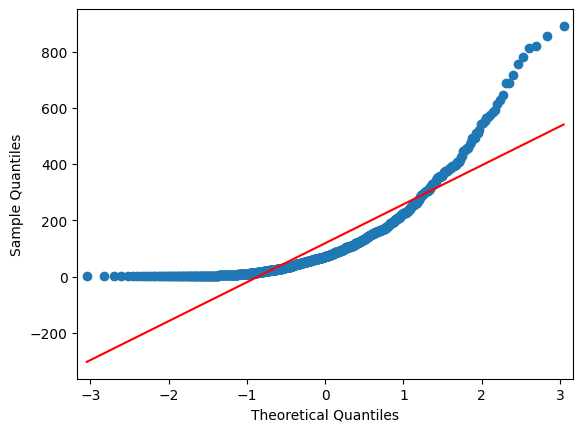

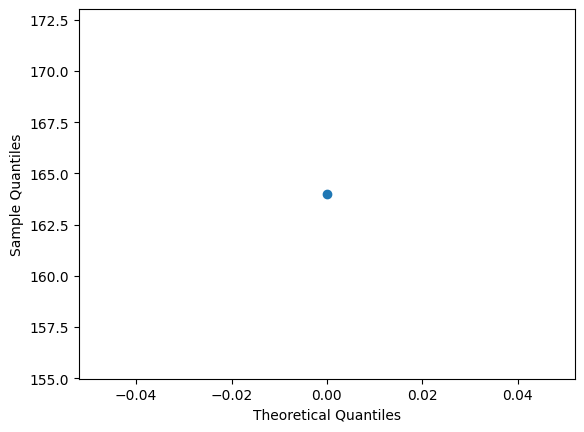

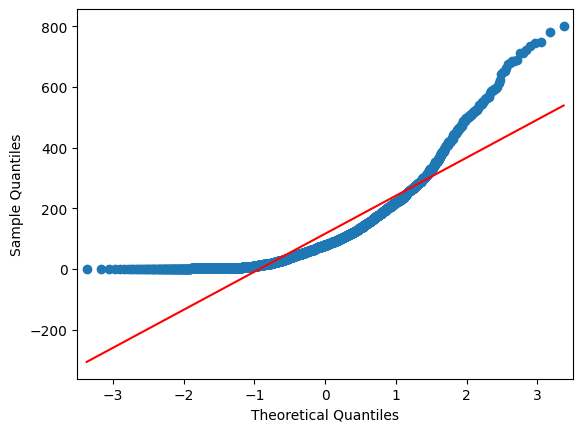

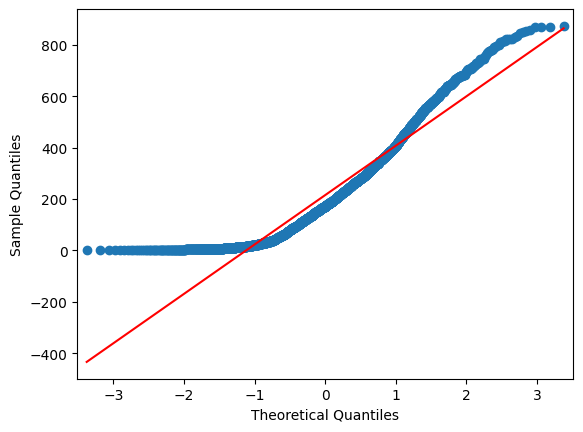

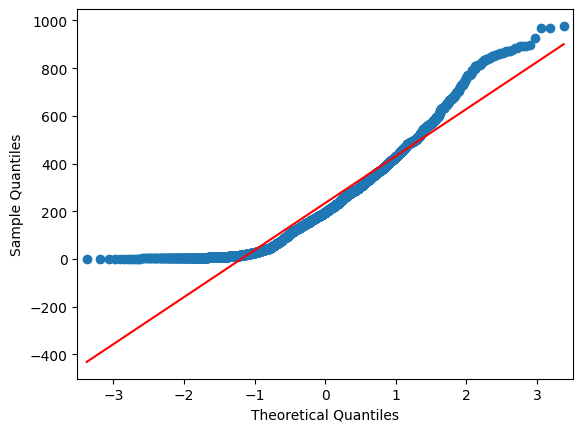

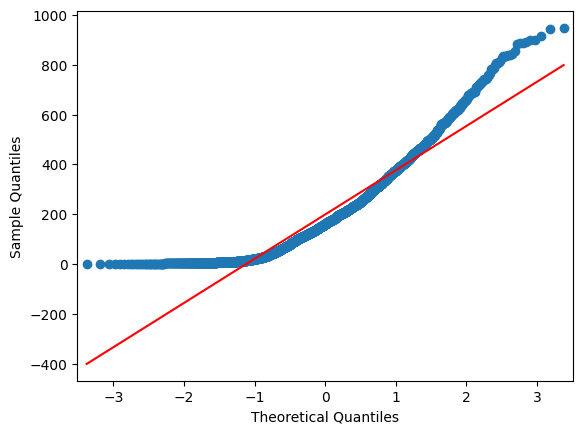

In [ ]:
index = 0
for row in range(4):
    for col in range(2):
        qqplot(groups[index], line="s")
        index += 1

plt.show()

As per above graphs, all groups are not following Gaussian distribution.

### **Equal variance: Levene's Test**

In [ ]:
#Ho: Variances is similar in different weather and season.

#Ha: Variances is not similar in different weather and season.

#Significance level (alpha): 0.05
levene_stat, p_value = stats.levene(gp1,gp2,gp3,gp4,gp5,gp6,gp7,gp8)
print(p_value)
if p_value < 0.05:
    print("Reject the Null hypothesis.Variances are not equal")
else:
  print("Fail to Reject the Null hypothesis.Variances are  equal")

3.463531888897594e-148
Reject the Null hypothesis.Variances are not equal


**p_value:** 3.463531888897594e-148

Reject the Null hypothesis. Variances are not equal

As per QQ plot and Levene's Test, We cannot ANOVA Tes

###Assumptions of ANOVA fail, so we will be using **Kruskal**.

In [ ]:
#assumptions of ANOVA don't hold, we need Kruskal Wallis
kruskal_stat, p_value = stats.kruskal(gp1,gp2,gp3,gp4,gp5,gp6,gp7,gp8)
print("p_value===",p_value)
if p_value<0.05:
  print("Since p-value is less than 0.05, we reject the null hypothesis")

p_value=== 4.614440933900297e-191
Since p-value is less than 0.05, we reject the null hypothesis


Since p-value is less than 0.05, we reject the null hypothesis. This implies that Number of cycles rented is not similar in different weather and season conditions


# **INSIGHTS:**



*   The data is given from Timestamp('2011-01-01 00:00:00') to Timestamp('2012-12-19 23:00:00'). The total time period for which the data is given is '718 days 23:00:00'.

*   More bikes are usually rented in summer and fall compared to other seasons.

*   On holidays, there is an increase in the number of bike rentals.

*   On weekends and holidays, slightly more bikes are rented than on working days.
*   When the humidity is less than 20, the number of bike rentals is very low.


*   The number of bike rentals decreases during rainy, snowy, foggy, or thunderstorm weather.


*   The number of bike rentals decreases when the temperature is below 10 degrees.


*   Whenever the wind speed is greater than 35, the number of bike rentals is less.





# **RECOMMENDATIONS:**



*   During summer and fall seasons, it is recommended that the company should have more bikes in stock to be rented because the demand in these seasons is higher compared to other seasons.

*   Using the t-test, at alpha 5%, we see p-value greater than 0.05, hence we accept the H0. So we can say that the working day doesen't affect count of bikes booked on yulu because same usage is observed on non working days.

*  Yulu should focus on attracting more customers on working days and try to make it an alternate mode of work travel. Offering peak timing offers and high availability of Yulu bikes can attract more bookings during working days. This can help Yulu increase its customer base and revenue.


*   Using the Anova test, taking alpha as 5%, we still see p-value less than 0.05 hence we reject the H0 and accept HA that is yes the weather has an effect on the number of cycles rented out.

*   To increase its bike active users, Yulu needs to pay attention to the weather conditions. Yulu can use weather and customer profiling to come up with new product features that can attract more bookings. For example, Yulu can offer weather-specific discounts or promotions to encourage people to rent bikes during certain weather conditions. By understanding customer preferences and behaviour during different weather conditions, Yulu can tailor its services to meet the needs of its customers and attract more bookings.


*   Using Chi-square test, the p-value is much less than alpha at 5%, we reject the H0 and accept H1. The season has some influence on the weather. We say it with high confidence. The use of meteorological features will help in boosting the bookings.

*   On very low humid days, it is recommended that the company should have fewer bikes in stock to be rented.

*   Whenever the temperature is less than 10 degrees or on very cold days, it is recommended that the company should have fewer bikes in stock to be rented.

*   Whenever the wind speed is greater than 35 or in thunderstorms, it is recommended that the company should have fewer bikes in stock to be rented.






